In [1]:
import os
import pandas as pd
import numpy as np
from glob import glob
from scipy.spatial.distance import jensenshannon

# === CONFIGURATION ===
root_dir = 'COO-Decon-Noise'
results_dir = os.path.join(root_dir, 'Results-JSD-PredictedVSActual')
os.makedirs(results_dir, exist_ok=True)

method_map = ['BayesPrism', 'nuSVR', 'ReDeconv', 'CIBERSORTx', 'MuSiC', 'NNLS', 'QP']

method_to_prop = {
    'BayesPrism': 'TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt',
    'NNLS': 'TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt',
    'QP': 'TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt',
    'CIBERSORTx': 'TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt',
    'nuSVR': 'TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt',
    'MuSiC': 'TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt',
    'ReDeconv': 'TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt'
}

# === FIND ALL *_modified.txt FILES ===
all_files = sorted(glob(os.path.join(root_dir, "**/*_modified.txt"), recursive=True))
print(f"Found {len(all_files)} deconvolution result files.\n")

all_results = []

# === MAIN LOOP ===
for file_path in all_files:
    try:
        filename = os.path.basename(file_path)
        dir_path = os.path.dirname(file_path)
        dirname = os.path.basename(dir_path)

        # Extract noise level
        parts = dirname.split('-')
        noise_token = [p for p in parts if p.startswith("Noisy_phi")]
        if noise_token:
            noise_level = noise_token[0].replace("Noisy_phi", "").replace("_All", "")
        else:
            noise_level = "Unknown"

        # Identify method
        raw_method = filename.replace('_modified.txt', '')
        method = next((m for m in method_map if m in raw_method), None)

        if method is None:
            print(f"Could not determine method for {file_path}")
            continue

        prop_file = method_to_prop.get(method)

        if not prop_file:
            print(f"No proportion file mapping for {method}")
            continue

        prop_path = os.path.join(root_dir, prop_file)

        if not os.path.exists(prop_path):
            print(f"Proportions file missing: {prop_path}")
            continue

        # === LOAD AND CLEAN GROUND TRUTH ===
        prop_df = pd.read_csv(prop_path, sep='\t', index_col=0)

        prop_df.index = prop_df.index.astype(str).str.strip()
        prop_df.columns = prop_df.columns.astype(str).str.strip()

        if "TotalCells" in prop_df.columns:
            prop_df = prop_df.drop(columns=["TotalCells"])

        prop_df = prop_df.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Normalize true proportions to percentages
        prop_sums = prop_df.sum(axis=1)

        if (prop_sums == 0).any():
            print(f"Warning: {(prop_sums == 0).sum()} true-proportion rows sum to zero for {method}.")

        prop_df = (
            prop_df
            .div(prop_sums.replace(0, np.nan), axis=0)
            .multiply(100)
            .round(5)
            .fillna(0)
        )

        # === LOAD AND CLEAN DECON RESULTS ===
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        decon_df.index = decon_df.index.astype(str).str.strip()
        decon_df.columns = decon_df.columns.astype(str).str.strip()

        # Remove noise suffix from sample names
        decon_df.index = decon_df.index.str.replace(
            r'_phi\d+\.?\d*(?:e[+-]?\d+)?$',
            '',
            regex=True
        )

        decon_df = decon_df.apply(pd.to_numeric, errors='coerce').fillna(0)

        # === ALIGN SAMPLES AND COLUMNS ===
        common_samples = prop_df.index.intersection(decon_df.index)

        if common_samples.empty:
            print(f"No overlapping samples in {file_path}")
            continue

        missing_in_decon = set(prop_df.columns) - set(decon_df.columns)
        missing_in_prop = set(decon_df.columns) - set(prop_df.columns)

        n_missing_in_decon = len(missing_in_decon)
        n_extra_in_decon = len(missing_in_prop)

        if missing_in_decon or missing_in_prop:
            print(f"Column mismatch in {file_path}")
            if missing_in_decon:
                print(f"   Missing in decon: {missing_in_decon}")
            if missing_in_prop:
                print(f"   Missing in prop / extra in decon: {missing_in_prop}")

        # For MuSiC, add missing expected cell types as predicted 0
        if method == "MuSiC":
            expected_cols = prop_df.columns

            true_vals_df = prop_df.loc[common_samples, expected_cols].fillna(0)

            pred_vals_df = (
                decon_df
                .reindex(index=common_samples, columns=expected_cols, fill_value=0)
                .fillna(0)
            )

            if missing_in_decon:
                print(f"   MuSiC missing labels added as 0 for JSD: {missing_in_decon}")

        # For all other methods, keep original shared-column behaviour
        else:
            common_cols = prop_df.columns.intersection(decon_df.columns)

            if common_cols.empty:
                print(f"No overlapping columns in {file_path}")
                continue

            true_vals_df = prop_df.loc[common_samples, common_cols].fillna(0)
            pred_vals_df = decon_df.loc[common_samples, common_cols].fillna(0)

        sample_jsd = []
        skipped_samples = 0

        # === SAMPLE-WISE JSD ===
        for sample in common_samples:
            true_vec = true_vals_df.loc[sample].values.astype(float)
            pred_vec = pred_vals_df.loc[sample].values.astype(float)

            # Ensure non-negative values
            true_vec = np.clip(true_vec, 0, None)
            pred_vec = np.clip(pred_vec, 0, None)

            true_sum = true_vec.sum()
            pred_sum = pred_vec.sum()

            # Skip samples where either distribution is entirely zero
            if true_sum == 0 or pred_sum == 0:
                skipped_samples += 1
                continue

            # Normalize each sample independently
            true_vec = true_vec / true_sum
            pred_vec = pred_vec / pred_sum

            # scipy returns JS distance; square it for JS divergence
            js_distance = jensenshannon(true_vec, pred_vec, base=2)
            js_divergence = js_distance ** 2

            sample_jsd.append(js_divergence)

        n_samples = len(sample_jsd)

        if n_samples == 0:
            print(f"No valid sample-level JSD values for {dirname} | {method}")
            continue

        mean_jsd = np.mean(sample_jsd)
        median_jsd = np.median(sample_jsd)
        std_jsd = np.std(sample_jsd)
        min_jsd = np.min(sample_jsd)
        max_jsd = np.max(sample_jsd)

        print(
            f"{dirname} | {method} | Noise={noise_level} — "
            f"N={n_samples}, Skipped={skipped_samples}, "
            f"Mean JSD={mean_jsd:.6f}, Median JSD={median_jsd:.6f}, "
            f"SD={std_jsd:.6f}"
        )

        all_results.append([
            prop_file,
            dirname,
            method,
            noise_level,
            mean_jsd,
            median_jsd,
            std_jsd,
            min_jsd,
            max_jsd,
            n_samples,
            skipped_samples,
            n_missing_in_decon,
            n_extra_in_decon
        ])

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

# === SAVE SUMMARY TABLE ===
if all_results:
    results_df = pd.DataFrame(
        all_results,
        columns=[
            "ProportionsFile",
            "InputDir",
            "Method",
            "NoiseLevel",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    )

    results_df["Matrix"] = results_df["InputDir"].apply(
        lambda x: "_".join(x.split("_")[0:4])
    )

    results_df = results_df[
        [
            "ProportionsFile",
            "Matrix",
            "Method",
            "NoiseLevel",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    ]

    results_csv = os.path.join(results_dir, "All_JSD_Summary.csv")
    results_df.to_csv(results_csv, sep='\t', index=False)

    print(f"\nSaved JSD summary: {results_csv}")

else:
    print("\nNo valid JSD results to save.")

Found 63 deconvolution result files.

TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts | CIBERSORTx | Noise=100 — N=825, Skipped=0, Mean JSD=0.369930, Median JSD=0.355855, SD=0.122870
TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts | NNLS | Noise=100 — N=825, Skipped=0, Mean JSD=0.545698, Median JSD=0.536750, SD=0.160238
TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts | QP | Noise=100 — N=825, Skipped=0, Mean JSD=0.545861, Median JSD=0.540043, SD=0.168962
TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts | BayesPrism | Noise=100 — N=825, Skipped=0, Mean JSD=0.285127, Median JSD=0.266157, SD=0.122663
TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts | ReDeconv | Noise=100 — N=825, Skipped=0, Mean JSD=0.281120, Median JSD=0.271747, SD=0.090069
Column mismatch in /exports/eddie/scratch/s2556897/07_TSP_Noise_Deconvolution_v3/TSP-BDa_Outer_300_1500_10_Random_v2C-Noisy_phi100_All-Counts/TSP-HBA_Inner_100each_seed42_filtered_Random_v

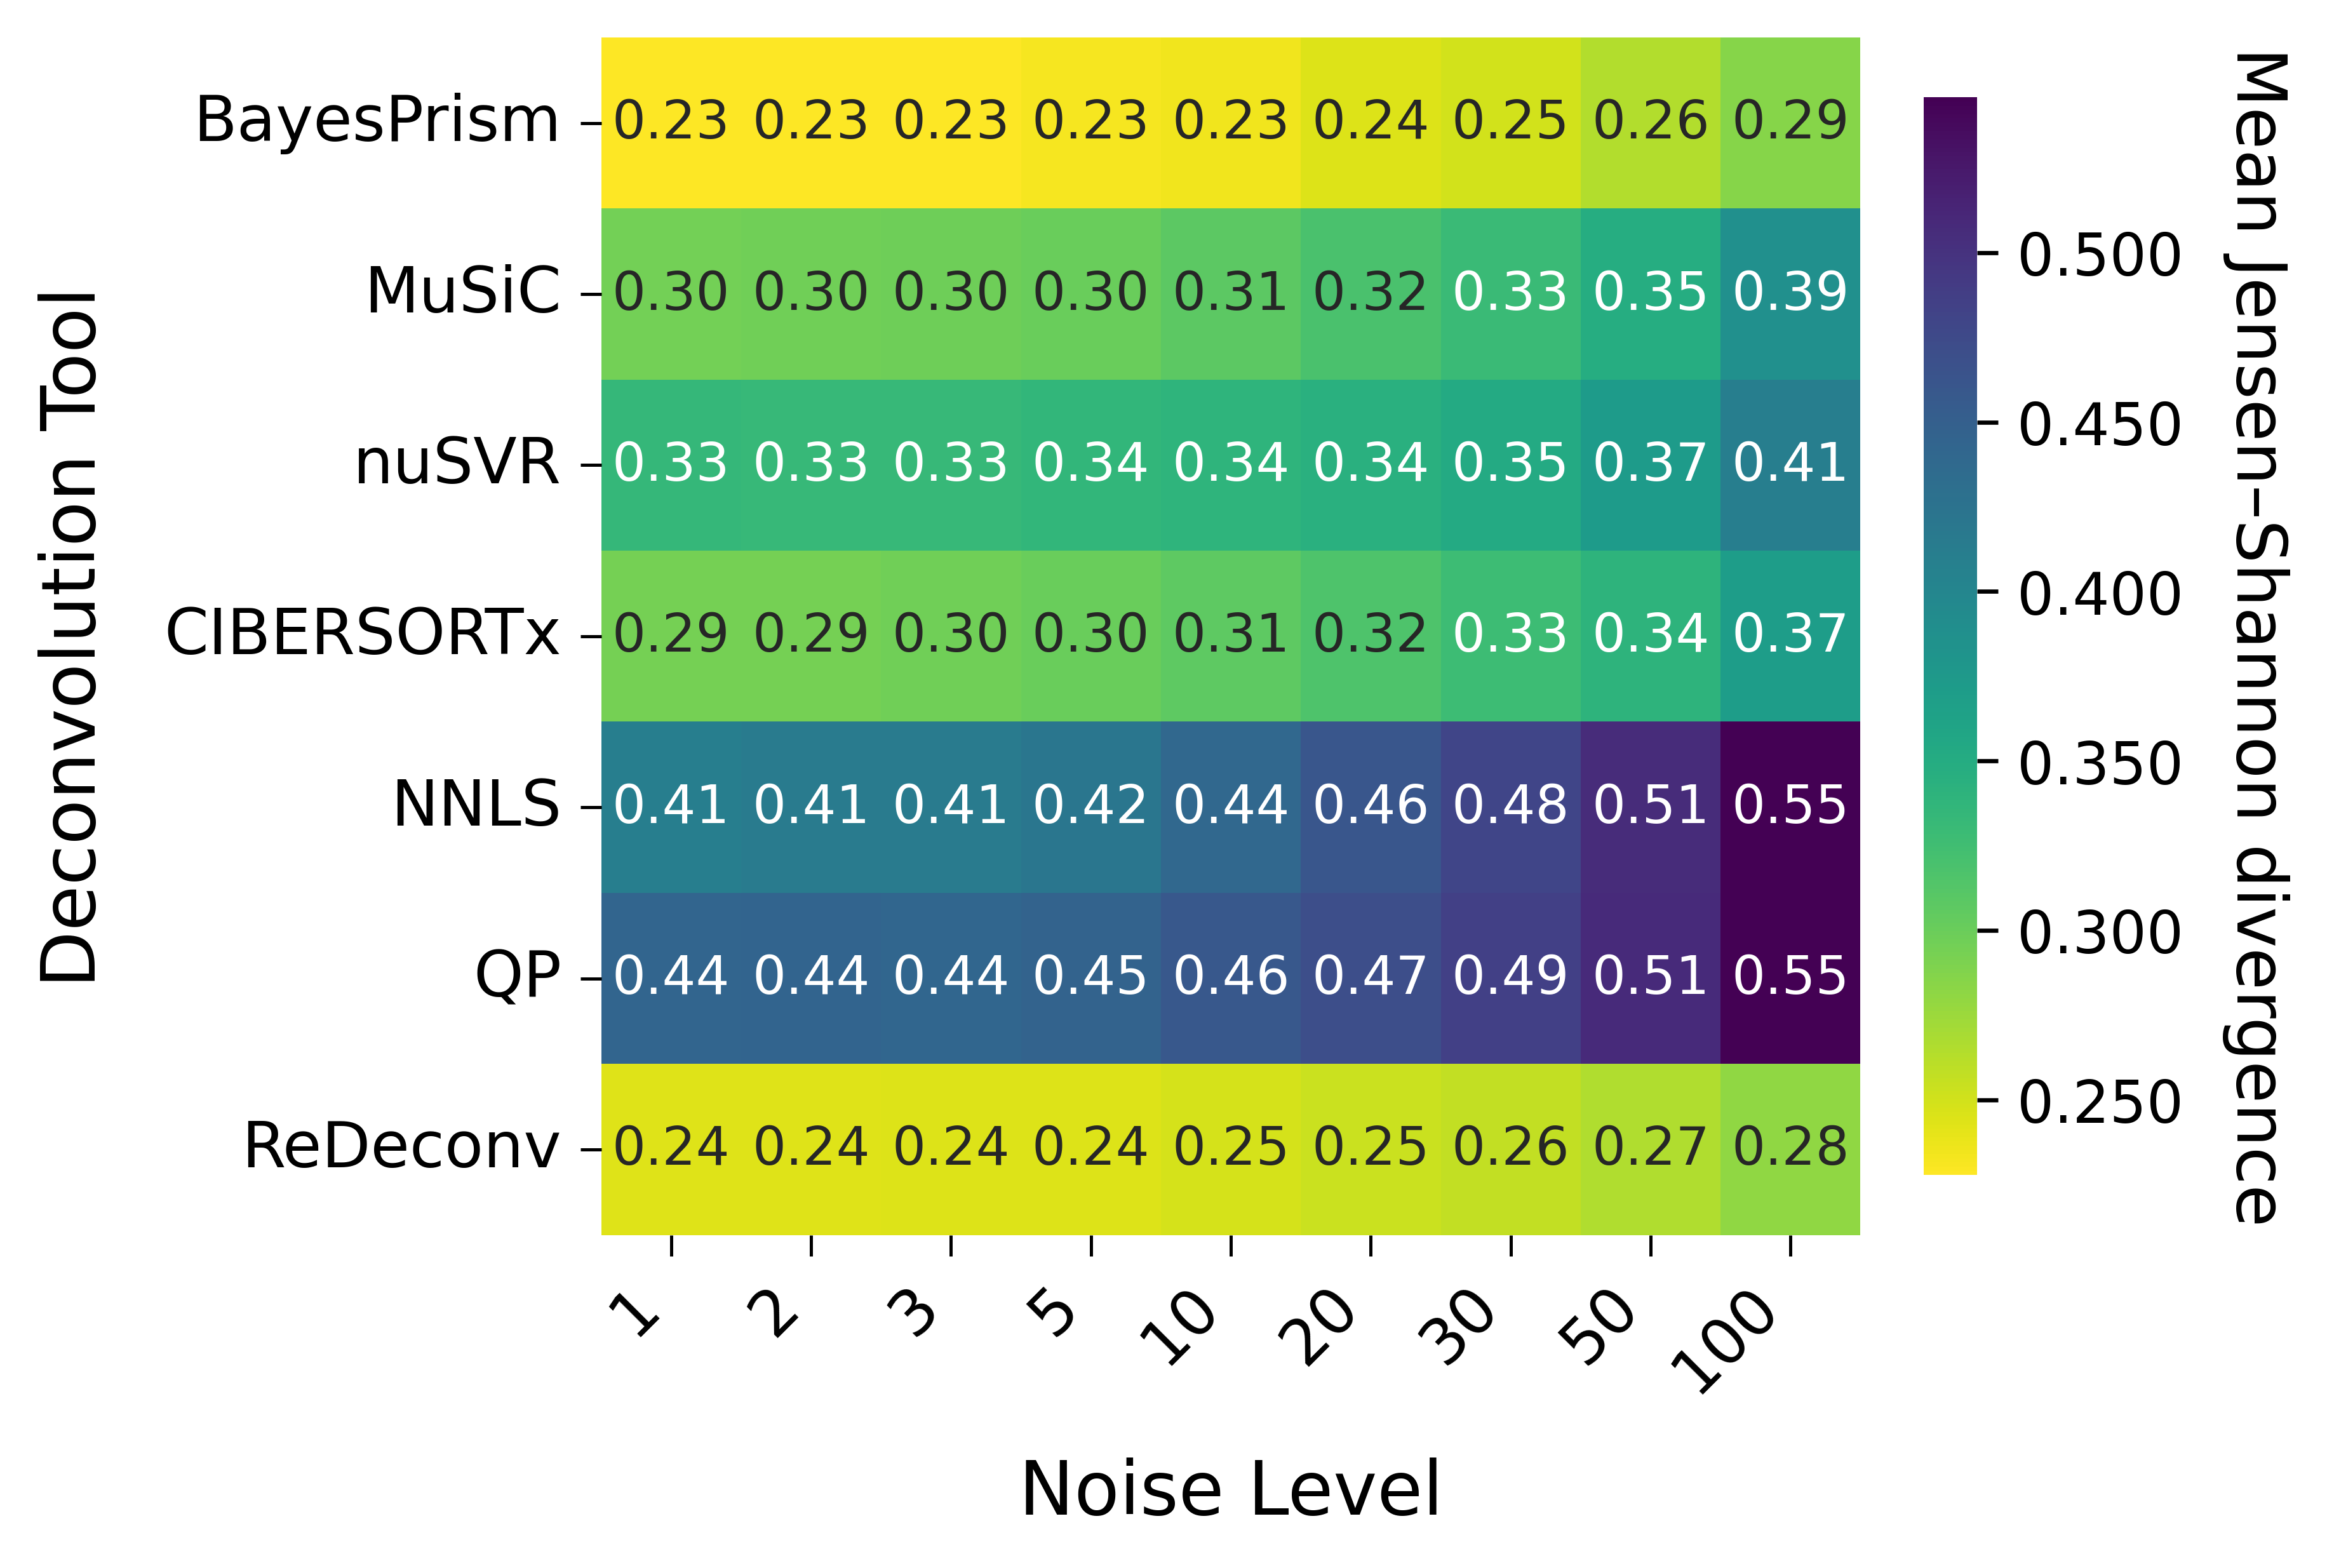

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# === LOAD DATA ===
file_path = 'COO-Decon-Noise/Results-JSD-PredictedVSActual/All_JSD_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# === ENSURE NUMERIC NOISE LEVEL FOR SORTING ===
df['NoiseLevelNumeric'] = pd.to_numeric(df['NoiseLevel'], errors='coerce')

# === GROUP & AVERAGE ===
agg_df = (
    df.groupby(['Method', 'NoiseLevelNumeric'], as_index=False)['Mean_JS_divergence']
    .mean()
)

# === PIVOT TO METHOD × NOISE LEVEL MATRIX ===
pivot_df = agg_df.pivot_table(
    index='Method',
    columns='NoiseLevelNumeric',
    values='Mean_JS_divergence'
).sort_index(axis=1)

# === REORDER ROWS ===
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
pivot_df = pivot_df.reindex(method_order)

# === SET COLOR SCALE ===
vmax = pivot_df.max().max()

# === PLOT HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)

ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',          # lower JSD = better
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cbar_kws={'label': 'Mean JSD', 'shrink': 0.9},
    linewidths=0,
    linecolor='white',
    vmax=vmax
)

# === AXIS & COLORBAR STYLING ===
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, length=4, width=0.6)
ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, length=4, width=0.6)

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Mean Jensen–Shannon divergence", fontsize=13, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=11, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

# === LABELS ===
plt.ylabel('Deconvolution Tool', fontsize=14, labelpad=10)
plt.xlabel('Noise Level', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# === SAVE & SHOW ===
out_path = 'COO-Decon-Noise/Mean_JSD_Heatmap_NoiseLevels.svg'

fig.savefig(out_path, bbox_inches='tight')
plt.show()
plt.close(fig)

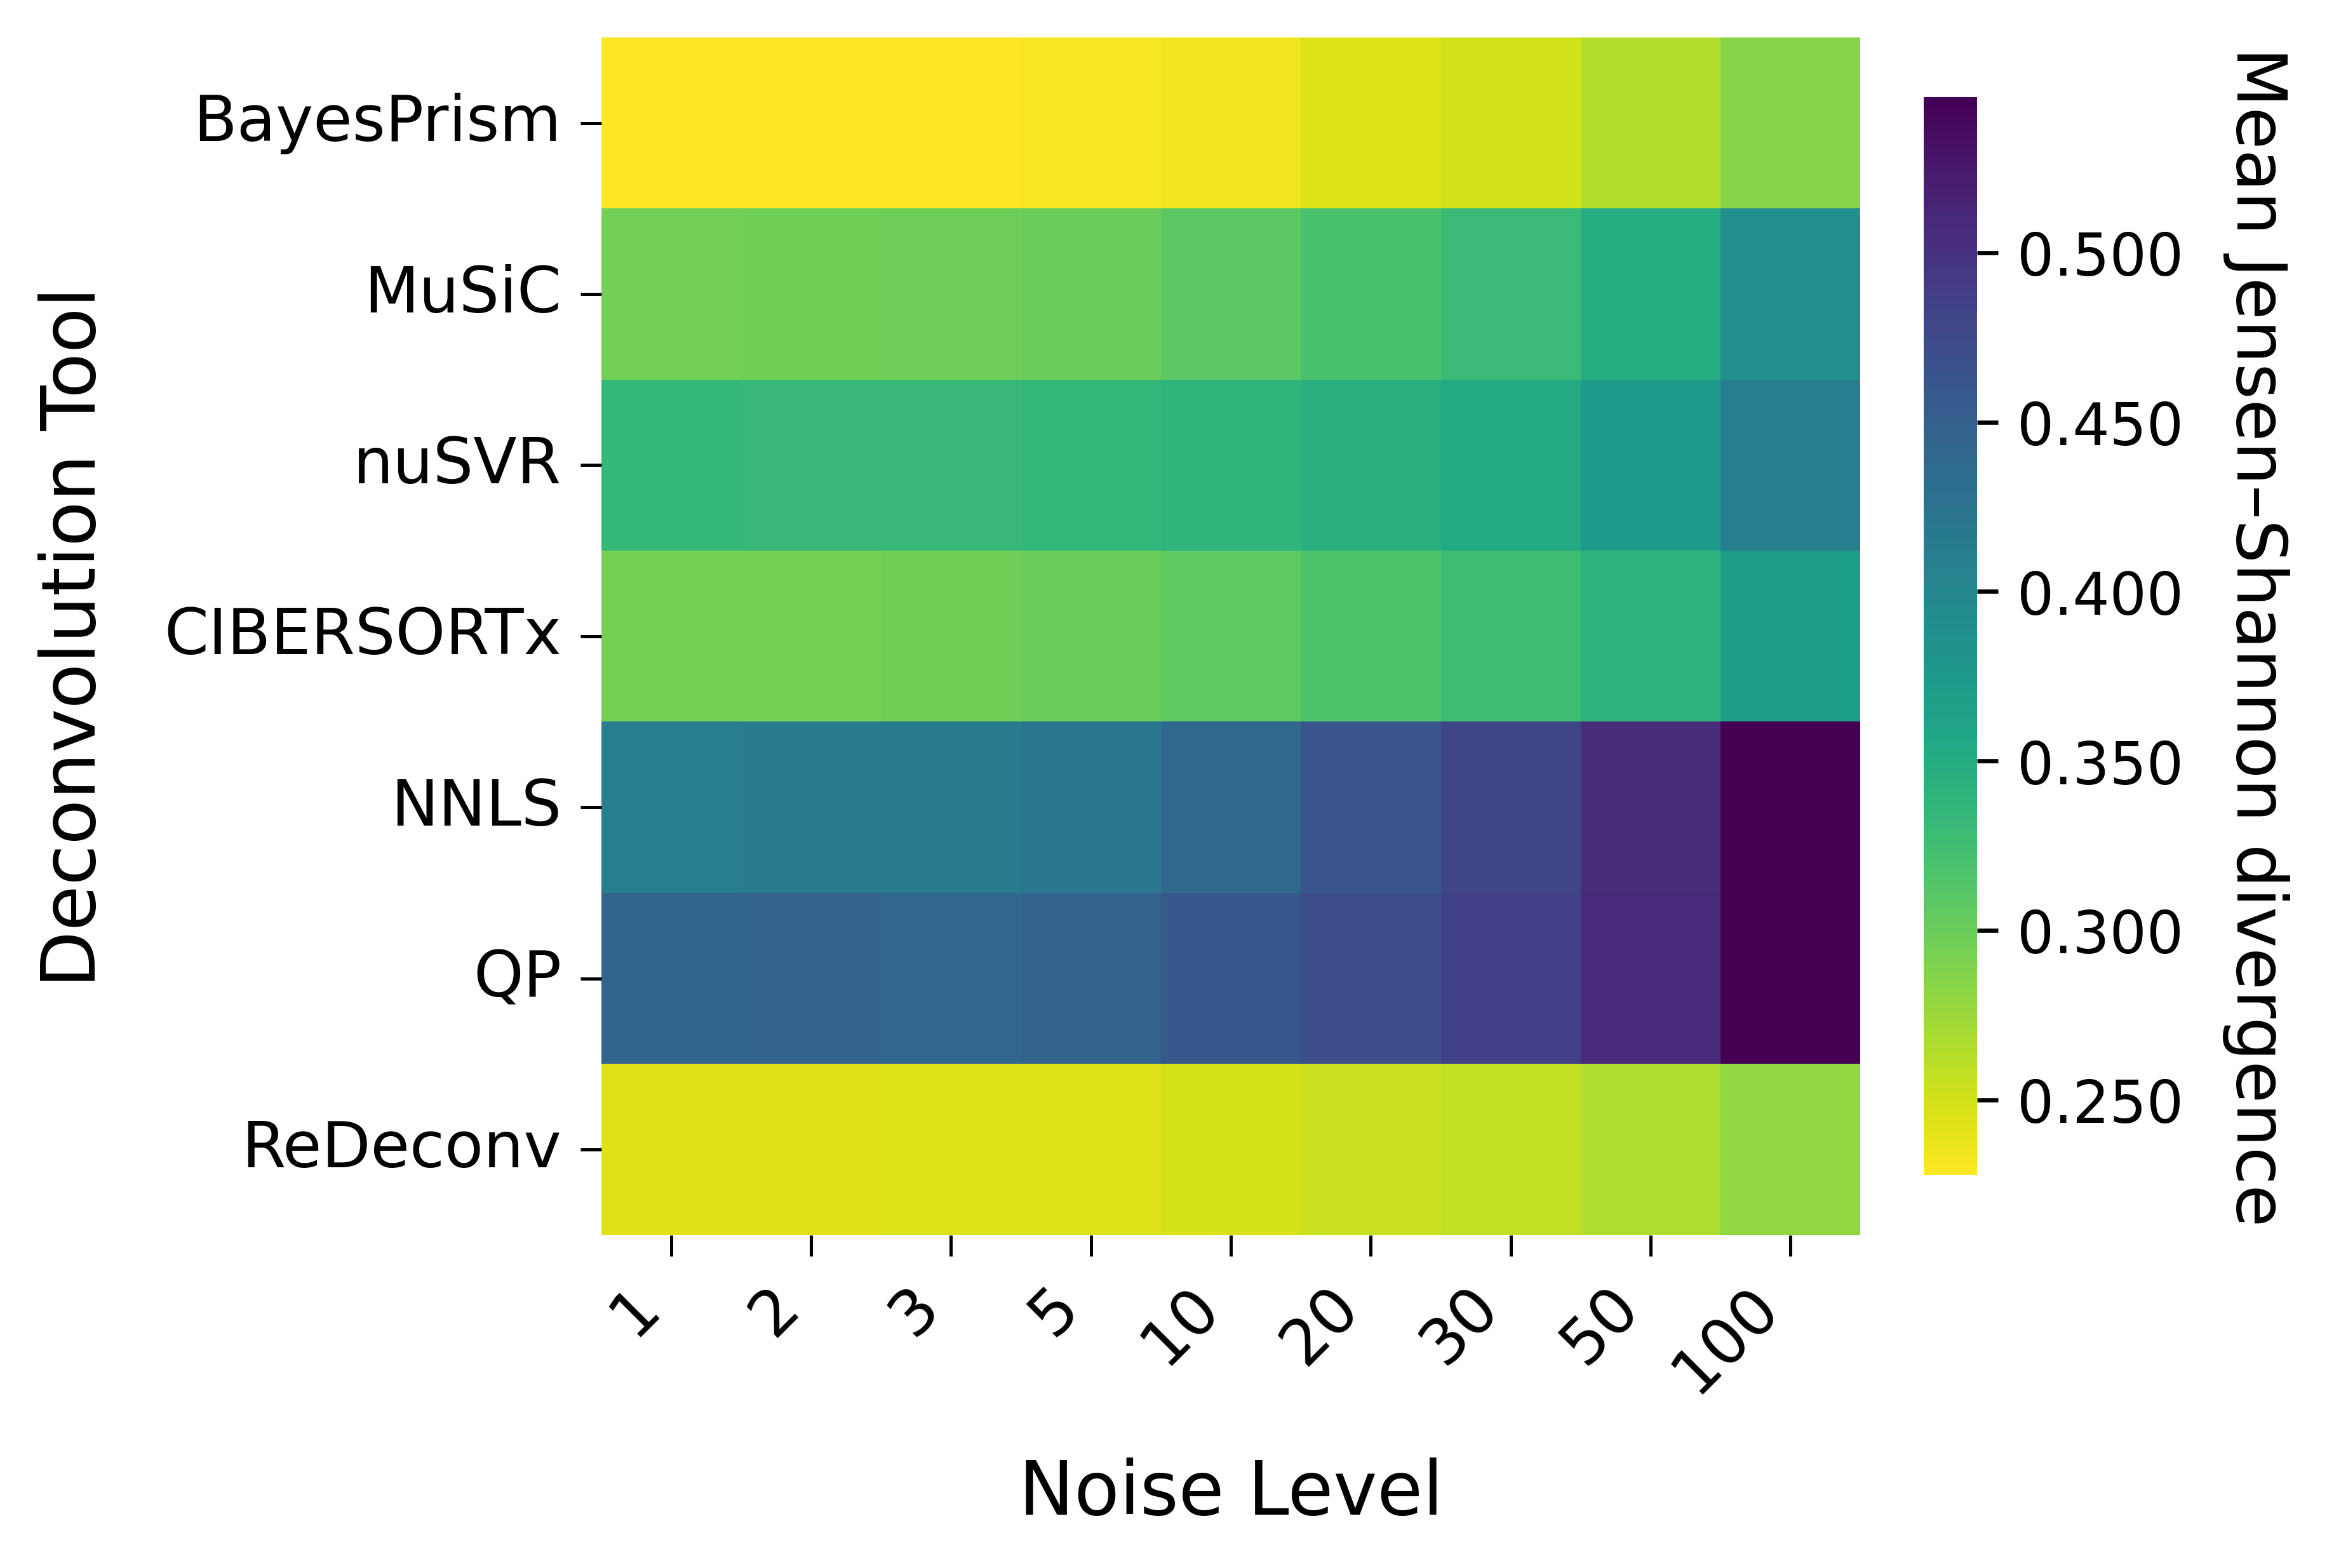

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# === LOAD DATA ===
file_path = 'COO-Decon-Noise/Results-JSD-PredictedVSActual/All_JSD_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# === ENSURE NUMERIC NOISE LEVEL FOR SORTING ===
df['NoiseLevelNumeric'] = pd.to_numeric(df['NoiseLevel'], errors='coerce')

# === GROUP & AVERAGE ===
agg_df = (
    df.groupby(['Method', 'NoiseLevelNumeric'], as_index=False)['Mean_JS_divergence']
    .mean()
)

# === PIVOT TO METHOD × NOISE LEVEL MATRIX ===
pivot_df = agg_df.pivot_table(
    index='Method',
    columns='NoiseLevelNumeric',
    values='Mean_JS_divergence'
).sort_index(axis=1)

# === REORDER ROWS ===
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
pivot_df = pivot_df.reindex(method_order)

# === SET COLOR SCALE ===
vmax = pivot_df.max().max()

# === PLOT HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)

ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',          # lower JSD = better
#    annot=True,
#    fmt=".3f",
#    annot_kws={"size": 10},
    cbar_kws={'label': 'Mean JSD', 'shrink': 0.9},
    linewidths=0,
    linecolor='white',
    vmax=vmax
)

# === AXIS & COLORBAR STYLING ===
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, length=4, width=0.6)
ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, length=4, width=0.6)

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Mean Jensen–Shannon divergence", fontsize=13, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=11, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

# === LABELS ===
plt.ylabel('Deconvolution Tool', fontsize=14, labelpad=10)
plt.xlabel('Noise Level', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# === SAVE & SHOW ===
out_path = 'COO-Decon-Noise/Mean_JSD_Heatmap_NoiseLevels_Clean.svg'

fig.savefig(out_path, bbox_inches='tight')
plt.show()
plt.close(fig)